<a href="https://colab.research.google.com/github/radhasundar/datamining/blob/main/exercise10_kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Excercise 10- K-Means -Clustering**

import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


create the dataset

In [2]:
data= {
    'Age':[22,25,28,30,35,40,45,50,52, 55],
    'Income':[20,25,28,30,35,45,50,55,60,65]
}


In [3]:
#convert data into dataframe
df=pd.DataFrame(data)
df


,Age,Income
0,22,20
1,25,25
2,28,28
3,30,30
4,35,35
5,40,45
6,45,50
7,50,55
8,52,60
9,55,65


In [ ]:
#from google.colab import drive

#drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Age     10 non-null     int64
 1   Income  10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes


In [5]:
df.shape

(10, 2)

check for null values

In [6]:
df.isnull().any()

,0
Age,False
Income,False


In [8]:
#use elbow method to find optimal cluster
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)
  kmeans.fit(df[['Age','Income']])
  wcss.append(kmeans.inertia_)

In [9]:
#display WCSS value
print("wcss value")
for k,value in zip(range(1,11),wcss):
  print("k=",k,"WCSS :",value)

wcss value
k= 1 WCSS : 3531.7000000000003
k= 2 WCSS : 614.4
k= 3 WCSS : 310.8666666666667
k= 4 WCSS : 156.66666666666669
k= 5 WCSS : 108.5
k= 6 WCSS : 60.5
k= 7 WCSS : 35.5
k= 8 WCSS : 18.5
k= 9 WCSS : 4.0
k= 10 WCSS : 0.0


Text(0, 0.5, 'WCSS')

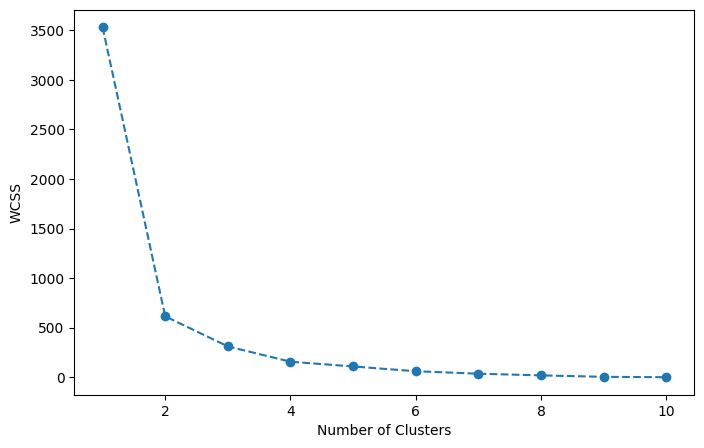

In [10]:
#plot
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o',linestyle='--')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

In [11]:
# Create K-Means model
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10)

In [12]:
#perform clustering
df['Cluster']=kmeans.fit_predict(df[['Age','Income']])


In [13]:
#display clustered data
print("\n clustered data:")
print(df)


 clustered data:
   Age  Income  Cluster
0   22      20        2
1   25      25        2
2   28      28        0
3   30      30        0
4   35      35        0
5   40      45        3
6   45      50        3
7   50      55        1
8   52      60        1
9   55      65        1


In [14]:
# display clustered centroids
print("\n cluster centroid: ")
print(kmeans.cluster_centers_)


 cluster centroid: 
[[31.         31.        ]
 [52.33333333 60.        ]
 [23.5        22.5       ]
 [42.5        47.5       ]]


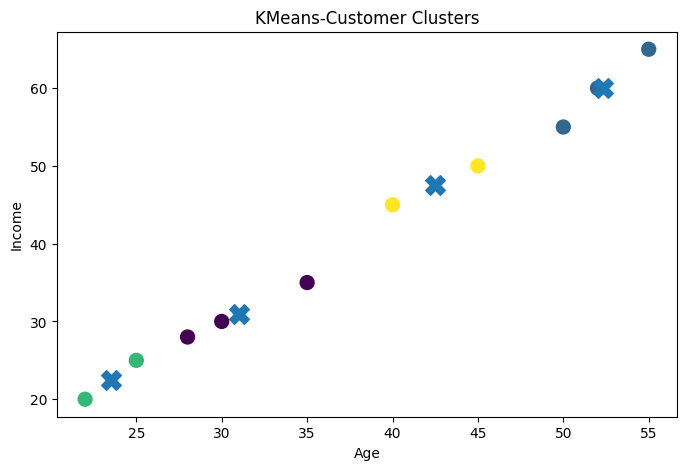

In [15]:
#plot the clusters
plt.figure(figsize=(8,5))
plt.scatter(
    df['Age'],
    df['Income'],
    c=df['Cluster'],
   s=100
)

#plot cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
      s=200,
    marker='X'
)
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("KMeans-Customer Clusters")
plt.show()